<a href="https://colab.research.google.com/github/Anikettcoder/ResQVision/blob/feature%2Fdata_preparation/notebooks/01_Data_Preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os                                                                    #File and folder management

PROJECT_DIR = "/content/drive/MyDrive/ResQVision"

print("Does the project folder exist?")
print(os.path.exists(PROJECT_DIR))

Does the project folder exist?
True


*Now that we know the folder exists, let's see what's inside*

In [3]:
print(os.listdir(PROJECT_DIR))

['Datasets', 'Models', 'Notebooks', 'Outputs', 'Docs', 'References', 'Assets', 'Presentation']


### Import the Libraries We Need

In [4]:
import glob                                                        # Helps us find files using patterns.
import shutil                                                      # This is used for file operations.(copy, move, delete dir)
import random                                                      # We need this because later we'll randomly select images.

import cv2                                                    # Reading & Resizing images, Drawing bounding boxes, Image & Video processing
import numpy as np                                            # image dimensions, numerical calculations, bounding-box calculations, statistics
import pandas as pd                                           # annotation analysis, experiment results
import matplotlib.pyplot as plt

In [5]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cu128
CUDA available: True


In [6]:
# Dataset folders
DATASET_DIR = os.path.join(PROJECT_DIR, "Datasets")

RAW_DIR = os.path.join(DATASET_DIR, "Raw")

PROCESSED_DIR = os.path.join(DATASET_DIR, "Processed")

# Output folder
OUTPUT_DIR = os.path.join(PROJECT_DIR, "Outputs")

print("Project:", PROJECT_DIR)
print("Raw datasets:", RAW_DIR)
print("Processed datasets:", PROCESSED_DIR)
print("Outputs:", OUTPUT_DIR)

Project: /content/drive/MyDrive/ResQVision
Raw datasets: /content/drive/MyDrive/ResQVision/Datasets/Raw
Processed datasets: /content/drive/MyDrive/ResQVision/Datasets/Processed
Outputs: /content/drive/MyDrive/ResQVision/Outputs


### Create visdrone path

In [7]:
VISDRONE_DIR = os.path.join(RAW_DIR, "VisDrone")

print("VisDrone directory:")
print(VISDRONE_DIR)

VisDrone directory:
/content/drive/MyDrive/ResQVision/Datasets/Raw/VisDrone


### File Structure

In [8]:
print("Files currently inside VisDrone folder:")

for item in os.listdir(VISDRONE_DIR):
    print("-", item)

Files currently inside VisDrone folder:
- Object detection in video
- Object detection in image
- Multi-Object tracking


---

### Now we will use the VisDrone Object Detection in Image dataset

In [9]:
VISDRONE_ROOT = os.path.join( RAW_DIR, "VisDrone", "Object detection in image")

print("VisDrone DET path:")
print(VISDRONE_ROOT)

VisDrone DET path:
/content/drive/MyDrive/ResQVision/Datasets/Raw/VisDrone/Object detection in image


In [10]:
print("Contents of VisDrone Object Detection in Image:")

for item in os.listdir(VISDRONE_ROOT):
    print("-", item)

Contents of VisDrone Object Detection in Image:
- VisDrone2019-DET-train
- VisDrone2019-DET-val


Exploring training data & validation data

In [11]:
# Path to VisDrone training dataset
TRAIN_DIR = os.path.join( VISDRONE_ROOT, "VisDrone2019-DET-train" )

# Path to VisDrone validation dataset
VAL_DIR = os.path.join( VISDRONE_ROOT, "VisDrone2019-DET-val" )

print("Training dataset:")
print(TRAIN_DIR)

print("\nValidation dataset:")
print(VAL_DIR)

Training dataset:
/content/drive/MyDrive/ResQVision/Datasets/Raw/VisDrone/Object detection in image/VisDrone2019-DET-train

Validation dataset:
/content/drive/MyDrive/ResQVision/Datasets/Raw/VisDrone/Object detection in image/VisDrone2019-DET-val


In [12]:
print("Contents of training dataset:\n")

for item in os.listdir(TRAIN_DIR):
    print("-", item)
print("\n")
print("Contents of validation dataset:\n")

for item in os.listdir(VAL_DIR):
    print("-", item)

Contents of training dataset:

- annotations
- images


Contents of validation dataset:

- .DS_Store
- images
- annotations


Exploring images

In [13]:
TRAIN_IMAGES_DIR = os.path.join( TRAIN_DIR, "images")

train_images = glob.glob( os.path.join( TRAIN_IMAGES_DIR, "*.jpg" ))
print("Number of train images:", len(train_images))

VAL_IMAGES_DIR = os.path.join( VAL_DIR, "images")

val_images = glob.glob( os.path.join( VAL_IMAGES_DIR, "*.jpg" ))
print("Number of val images:", len(val_images))

Number of train images: 6471
Number of val images: 548


Exploring annotations

In [14]:

TRAIN_ANNOTATIONS_DIR = os.path.join(TRAIN_DIR, "annotations")

train_annotations = glob.glob( os.path.join (TRAIN_ANNOTATIONS_DIR, "*.txt"))
print("Number of val annotations: ", len(train_annotations))


VAL_ANNOTATIONS_DIR = os.path.join(VAL_DIR, "annotations")

val_annotations = glob.glob( os.path.join (VAL_ANNOTATIONS_DIR, "*.txt"))
print("Number of val annotations: ", len(val_annotations))

Number of val annotations:  6471
Number of val annotations:  548


### CLEANING DATA

In [15]:
#FOR TRAINING SET
train_image_names = {
    os.path.splitext(os.path.basename(path))[0]
    for path in train_images
}

train_annotation_names = {
    os.path.splitext(os.path.basename(path))[0]
    for path in train_annotations
}

missing_annotations = ( train_image_names - train_annotation_names
)

extra_annotations = ( train_annotation_names - train_image_names )

print( "Images without annotations:", len(missing_annotations))

print( "Annotations without images:", len(extra_annotations))

Images without annotations: 0
Annotations without images: 0


In [16]:
#FOR VALIDATION SET
val_image_names = {
    os.path.splitext(os.path.basename(path))[0]
    for path in val_images
}

val_annotation_names = {
    os.path.splitext(os.path.basename(path))[0]
    for path in val_annotations
}

missing_val_annotations = ( val_image_names - val_annotation_names )

extra_val_annotations = ( val_annotation_names - val_image_names)

print( "Validation images without annotations:", len(missing_val_annotations))
print( "Validation annotations without images:", len(extra_val_annotations))

Validation images without annotations: 0
Validation annotations without images: 0


In [17]:
from collections import Counter

category_counter = Counter()

for annotation_file in train_annotations:

    with open(annotation_file, "r") as file:

        for line in file:

            values = line.strip().split(",")

            if len(values) >= 6:

                category = int(values[5])

                category_counter[category] += 1

print("Category distribution:")
print(category_counter)

Category distribution:
Counter({4: 144867, 1: 79337, 10: 29647, 2: 27059, 5: 24956, 6: 12875, 3: 10480, 0: 8813, 9: 5926, 7: 4812, 8: 3246, 11: 1532})


In [22]:
# Select the first training image
sample_image = train_images[0]

# Extract only the filename without .jpg
sample_name = os.path.splitext(
    os.path.basename(sample_image)
)[0]

# Create the corresponding annotation path
sample_annotation = os.path.join(
    TRAIN_ANNOTATIONS_DIR,
    sample_name + ".txt"
)

print("Sample image:")
print(sample_image)

print("\nSample annotation:")
print(sample_annotation)

Sample image:
/content/drive/MyDrive/ResQVision/Datasets/Raw/VisDrone/Object detection in image/VisDrone2019-DET-train/images/9999990_00000_d_0000077.jpg

Sample annotation:
/content/drive/MyDrive/ResQVision/Datasets/Raw/VisDrone/Object detection in image/VisDrone2019-DET-train/annotations/9999990_00000_d_0000077.txt


In [23]:
with open(
    sample_annotation,
    "r",
    encoding="utf-8"
) as file:

    annotation_lines = file.readlines()

print("Number of objects:", len(annotation_lines))

print("\nFirst 10 annotation lines:")

for line in annotation_lines[:10]:
    print(line.strip())

Number of objects: 52

First 10 annotation lines:
842,950,13,19,1,1,0,0
805,897,10,13,1,1,0,0
953,577,17,18,1,2,0,0
1110,460,16,25,1,1,0,0
1073,405,15,21,1,1,0,1
822,195,17,20,1,2,0,0
815,188,18,17,1,2,0,1
850,108,18,27,1,1,0,0
330,24,24,32,1,2,0,0
250,82,22,28,1,1,0,0


In [24]:
image = cv2.imread(sample_image)                                                 # cv2.imread() -> returns an image as a NumPy array.

image_rgb = cv2.cvtColor(                                                        # open cv read image -> BGR
    image,                                                                       # matplotlib read images  -> RGB
    cv2.COLOR_BGR2RGB                                                            # to convert BGR -> RGB
)

print("Image shape:")
print(image_rgb.shape)

Image shape:
(1050, 1400, 3)


### Display the original image

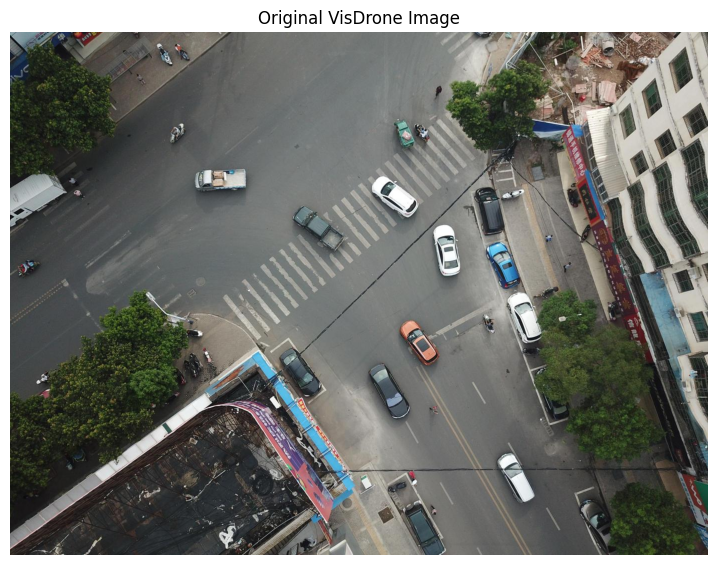

In [35]:
plt.figure(figsize=(9, 9))                                                       # At this point there should be no boxes.
                                                                                 # That's intentional.
plt.imshow(image_rgb)

plt.axis("off")
plt.title("Original VisDrone Image")
plt.show()

## **Draw human bounding boxes**

In [36]:
visualized_image = image_rgb.copy()

for line in annotation_lines:
    values = line.strip().split(",")

    if len(values) < 8:
        continue

    x = int(values[0])
    y = int(values[1])
    width = int(values[2])
    height = int(values[3])
    score = int(values[4])
    category = int(values[5])

    # Keep only valid human annotations
    if score == 1 and category in [1, 2]:
                                                                                 # To calculate botom-right corner
        x2 = x + width                                                           # VisDrone gives us: top-left corner + width + height
        y2 = y + height                                                          # Open CV needs -> top-left + botton-right

        cv2.rectangle(
            visualized_image,
            (x, y),
            (x2, y2),
            (255, 0, 0),
            2
        )

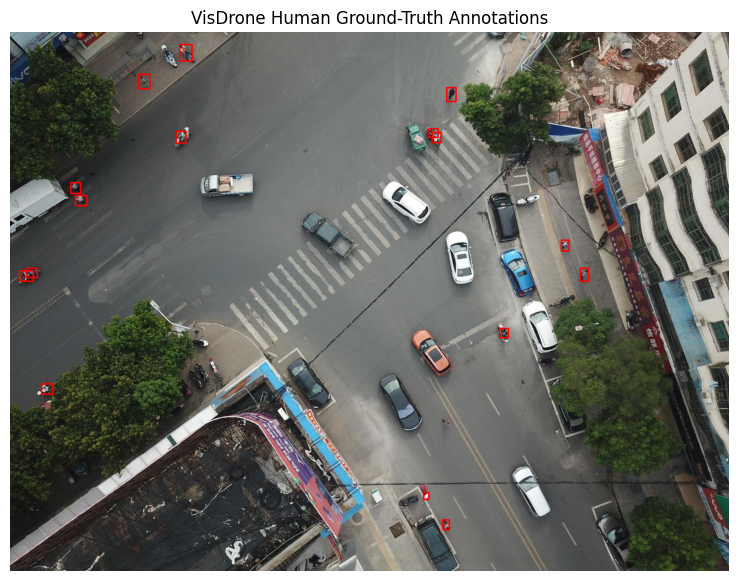

In [39]:
plt.figure(figsize=(12, 7))

plt.imshow(visualized_image)

plt.axis("off")

plt.title("VisDrone Human Ground-Truth Annotations")
plt.show()

In [40]:
human_objects = 0

for line in annotation_lines:

    values = line.strip().split(",")

    if len(values) < 8:
        continue

    score = int(values[4])
    category = int(values[5])

    if score == 1 and category in [1, 2]:

        human_objects += 1

print(
    "Human objects in this image:",
    human_objects
)

Human objects in this image: 16


In [41]:
for i, line in enumerate(annotation_lines):

    values = line.strip().split(",")

    if len(values) < 8:
        continue

    x = int(values[0])
    y = int(values[1])
    width = int(values[2])
    height = int(values[3])

    score = int(values[4])
    category = int(values[5])
    truncation = int(values[6])
    occlusion = int(values[7])

    print(
        f"Object {i}: "
        f"x={x}, y={y}, "
        f"w={width}, h={height}, "
        f"score={score}, "
        f"category={category}, "
        f"truncation={truncation}, "
        f"occlusion={occlusion}"
    )

Object 0: x=842, y=950, w=13, h=19, score=1, category=1, truncation=0, occlusion=0
Object 1: x=805, y=897, w=10, h=13, score=1, category=1, truncation=0, occlusion=0
Object 2: x=953, y=577, w=17, h=18, score=1, category=2, truncation=0, occlusion=0
Object 3: x=1110, y=460, w=16, h=25, score=1, category=1, truncation=0, occlusion=0
Object 4: x=1073, y=405, w=15, h=21, score=1, category=1, truncation=0, occlusion=1
Object 5: x=822, y=195, w=17, h=20, score=1, category=2, truncation=0, occlusion=0
Object 6: x=815, y=188, w=18, h=17, score=1, category=2, truncation=0, occlusion=1
Object 7: x=850, y=108, w=18, h=27, score=1, category=1, truncation=0, occlusion=0
Object 8: x=330, y=24, w=24, h=32, score=1, category=2, truncation=0, occlusion=0
Object 9: x=250, y=82, w=22, h=28, score=1, category=1, truncation=0, occlusion=0
Object 10: x=323, y=193, w=19, h=23, score=1, category=2, truncation=0, occlusion=0
Object 11: x=118, y=293, w=19, h=21, score=1, category=1, truncation=0, occlusion=0
Ob

In [42]:
print("Human-related annotations:\n")

for i, line in enumerate(annotation_lines):

    values = line.strip().split(",")

    if len(values) < 8:
        continue

    x = int(values[0])
    y = int(values[1])
    width = int(values[2])
    height = int(values[3])

    score = int(values[4])
    category = int(values[5])
    truncation = int(values[6])
    occlusion = int(values[7])

    if category in [1, 2]:

        print(
            f"Object {i}: "
            f"x={x}, y={y}, "
            f"w={width}, h={height}, "
            f"score={score}, "
            f"category={category}, "
            f"truncation={truncation}, "
            f"occlusion={occlusion}"
        )

Human-related annotations:

Object 0: x=842, y=950, w=13, h=19, score=1, category=1, truncation=0, occlusion=0
Object 1: x=805, y=897, w=10, h=13, score=1, category=1, truncation=0, occlusion=0
Object 2: x=953, y=577, w=17, h=18, score=1, category=2, truncation=0, occlusion=0
Object 3: x=1110, y=460, w=16, h=25, score=1, category=1, truncation=0, occlusion=0
Object 4: x=1073, y=405, w=15, h=21, score=1, category=1, truncation=0, occlusion=1
Object 5: x=822, y=195, w=17, h=20, score=1, category=2, truncation=0, occlusion=0
Object 6: x=815, y=188, w=18, h=17, score=1, category=2, truncation=0, occlusion=1
Object 7: x=850, y=108, w=18, h=27, score=1, category=1, truncation=0, occlusion=0
Object 8: x=330, y=24, w=24, h=32, score=1, category=2, truncation=0, occlusion=0
Object 9: x=250, y=82, w=22, h=28, score=1, category=1, truncation=0, occlusion=0
Object 10: x=323, y=193, w=19, h=23, score=1, category=2, truncation=0, occlusion=0
Object 11: x=118, y=293, w=19, h=21, score=1, category=1, 

In [43]:
human_all = 0
human_valid = 0
human_ignored = 0

for line in annotation_lines:

    values = line.strip().split(",")

    if len(values) < 8:
        continue

    score = int(values[4])
    category = int(values[5])

    if category in [1, 2]:

        human_all += 1

        if score == 1:
            human_valid += 1

        elif score == 0:
            human_ignored += 1


print("Total human annotations:", human_all)
print("Valid human annotations:", human_valid)
print("Ignored human annotations:", human_ignored)

Total human annotations: 16
Valid human annotations: 16
Ignored human annotations: 0


In [44]:
from collections import Counter

category_counter = Counter()

for line in annotation_lines:

    values = line.strip().split(",")

    if len(values) < 8:
        continue

    category = int(values[5])

    category_counter[category] += 1


print("All categories in this image:")
print(category_counter)

All categories in this image:
Counter({10: 20, 4: 10, 1: 8, 2: 8, 6: 3, 5: 2, 8: 1})


In [45]:
category_names = {
    0: "ignored region",
    1: "pedestrian",
    2: "people",
    3: "bicycle",
    4: "car",
    5: "van",
    6: "truck",
    7: "tricycle",
    8: "awning-tricycle",
    9: "bus",
    10: "motor",
    11: "others"
}

for category, count in sorted(category_counter.items()):

    name = category_names.get(
        category,
        "unknown"
    )

    print(
        f"Category {category}: "
        f"{name} → {count} objects"
    )

Category 1: pedestrian → 8 objects
Category 2: people → 8 objects
Category 4: car → 10 objects
Category 5: van → 2 objects
Category 6: truck → 3 objects
Category 8: awning-tricycle → 1 objects
Category 10: motor → 20 objects


# Define the processed paths

In [48]:
# VISDRONE TO YOLO CONVERSION

PROCESSED_DIR = os.path.join( DATASET_DIR, "Processed", "VisDrone_YOLO" )

YOLO_IMAGES_TRAIN = os.path.join( PROCESSED_DIR, "images", "train" )
YOLO_IMAGES_VAL = os.path.join( PROCESSED_DIR, "images", "val" )

YOLO_LABELS_TRAIN = os.path.join( PROCESSED_DIR, "labels", "train" )
YOLO_LABELS_VAL = os.path.join( PROCESSED_DIR, "labels", "val" )

In [52]:
os.makedirs(
    YOLO_IMAGES_TRAIN,
    exist_ok=True
)

os.makedirs(
    YOLO_IMAGES_VAL,
    exist_ok=True
)

os.makedirs(
    YOLO_LABELS_TRAIN,
    exist_ok=True
)

os.makedirs(
    YOLO_LABELS_VAL,
    exist_ok=True
)

print("YOLO processed directories created successfully\n")
print("Processed dataset structure:\n")

print("Images train:")
print(YOLO_IMAGES_TRAIN)

print("\nImages val:")
print(YOLO_IMAGES_VAL)

print("\nLabels train:")
print(YOLO_LABELS_TRAIN)

print("\nLabels val:")
print(YOLO_LABELS_VAL)

YOLO processed directories created successfully

Processed dataset structure:

Images train:
/content/drive/MyDrive/ResQVision/Datasets/Processed/VisDrone_YOLO/images/train

Images val:
/content/drive/MyDrive/ResQVision/Datasets/Processed/VisDrone_YOLO/images/val

Labels train:
/content/drive/MyDrive/ResQVision/Datasets/Processed/VisDrone_YOLO/labels/train

Labels val:
/content/drive/MyDrive/ResQVision/Datasets/Processed/VisDrone_YOLO/labels/val
